# Exploratory Data Analysis (EDA)- Online Retail II Dataset

**Objective**
Thsi notebook explores the online Retail II dataset to understand its structure, identify data qualityissues, analyze product sales, investigate country performance, examine revenuer trends, detect outliers, and derive business insights before any data preprocessing or machine learning.

### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

# Display ploys as inside the notebook
%matplotlib inline


## 1. Load Dataset

In [27]:
df = pd.read_excel("../Data/online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### 1b. Dataset Overview

In [ ]:
df.shape 

(525461, 8)

In [ ]:
df.columns 

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [ ]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


## 2. Missing values and Duplicated values

In [ ]:
df.isnull().sum()



Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(6865)

## 3a. Top 10 best selling products by Quantity
The objective of this analysis is to identify the productswith the highest toatal quantity sold, as this will help the business understand customerdemandand inventory priorities.

In [ ]:
top_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_quantity

Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64

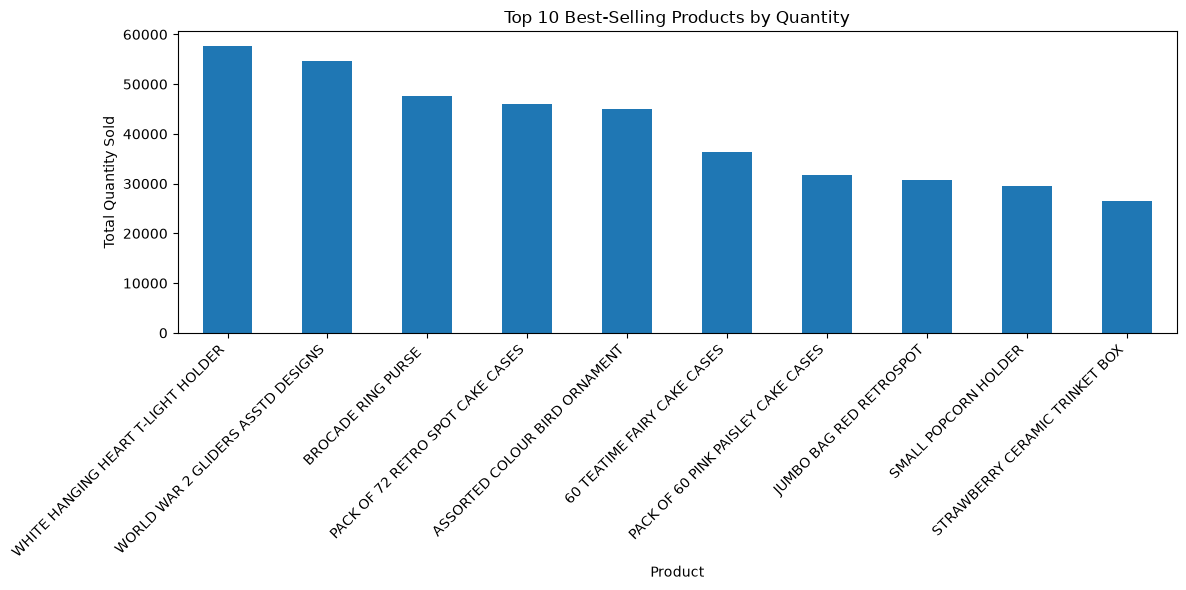

In [ ]:
plt.figure(figsize=(12,6))

top_quantity.plot(kind="bar")

plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 3b. Top 10 Products by Revenue
Revenue is calculated by multiplying thr quantity sold by the unit price. this analysis identifies the products that enerate the highest income for the busisness.

In [ ]:
# Create Revenue Column
df["Revenue"] = df["Quantity"] + df["Price"]

# Display first five rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,18.95
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,18.75
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,18.75
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,50.10
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,25.25


In [ ]:
top_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_revenue

Description
Manual                                538402.19
DOTCOM POSTAGE                        117146.43
AMAZON FEE                             79734.16
WHITE HANGING HEART T-LIGHT HOLDER     68630.48
WORLD WAR 2 GLIDERS ASSTD DESIGNS      54822.79
ASSORTED COLOUR BIRD ORNAMENT          47824.01
BROCADE RING PURSE                     47703.96
PACK OF 72 RETRO SPOT CAKE CASES       47078.25
REGENCY CAKESTAND 3 TIER               44479.40
60 TEATIME FAIRY CAKE CASES            37235.30
Name: Revenue, dtype: float64

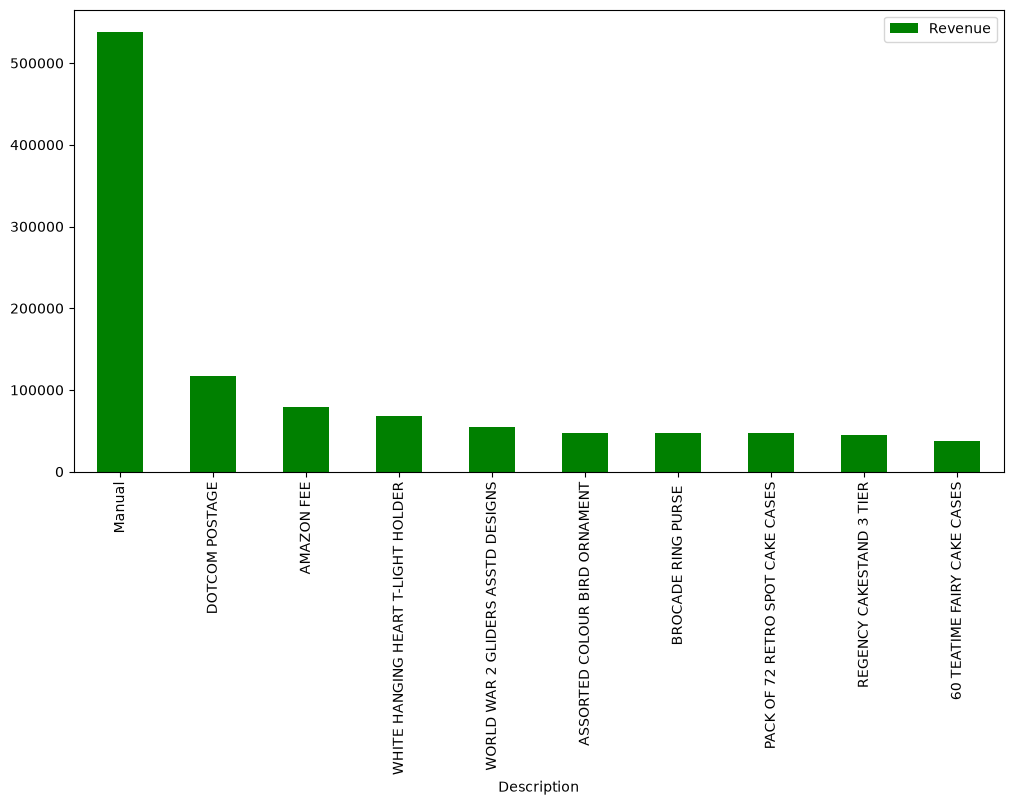

In [28]:
plt.figure(figsize=(12,6))

top_revenue.plot(
    kind="bar", 
    color="green",
    label="Revenue"
    
    
)

plt.legend()

### Observation
The products generating the highest revenue are not necessarily those sold in the greatest quantities. thsi indicates that unit price has a significant impact on overall revenue, and both sales volume and pricing should be consideredwhen making inventory and marketng decisions.

## 4. Sales Perfoormance by Country
This analysis evaluates how revenue is distributed across differet countriesto idetify key marketsand potential opportunities for business expansion.

In [ ]:
Country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      
)

Country_sales.head(10)

Country
United Kingdom    6636499.813
EIRE               265562.260
Denmark            228160.940
Netherlands        190993.680
Germany            137031.451
France              98652.320
Sweden              59141.090
Norway              42463.850
Switzerland         27289.190
Spain               26238.020
Name: Revenue, dtype: float64

## 5. Monthy Revenue Trend
This analysis examines how revenue changes over timeby aggregating monthly sales. 



In [ ]:
df["InvoiceDate"].head()

0   2009-12-01 07:45:00
1   2009-12-01 07:45:00
2   2009-12-01 07:45:00
3   2009-12-01 07:45:00
4   2009-12-01 07:45:00
Name: InvoiceDate, dtype: datetime64[us]

In [ ]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [ ]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()

)
monthly_revenue


Month
2009-12    618395.760
2010-01    541034.362
2010-02    485176.536
2010-03    757674.241
2010-04    472679.372
2010-05    506980.530
2010-06    623122.690
2010-07    402851.900
2010-08    609581.090
2010-09    702025.221
2010-10    867702.340
2010-11    975769.862
2010-12    332846.750
Freq: M, Name: Revenue, dtype: float64

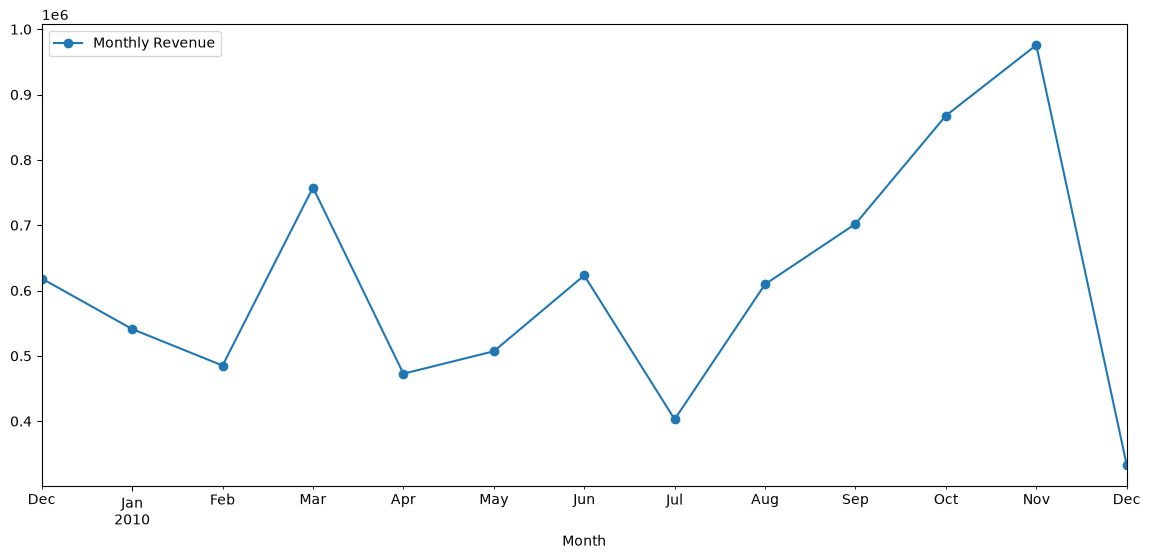

In [29]:
plt.figure(figsize=(14,6))

monthly_revenue.plot(
    marker="o",
    label="Monthly Revenue"
    
)


plt.legend()

### Observation 
The monthly revenue trend illustrates how sales changedthroughout the observationperiod. peaks may indicate seasonal demand or promotional campaigns, while declines may suggest reduced activity or market fluctuations

## 6. Correlation heatmap
correlation analysis measure the strength and the direction of relationship betweem numerical variables. A heatmap provides a visual representation of these relashionships and helps identify variables that may inluence one another. 

In [ ]:
#Select only numerical columns
Numeric_df=df.select_dtypes(include=["number"])

Numeric_df.head()

,Quantity,Price,Customer ID,Revenue
0,12,6.95,13085.0,18.95
1,12,6.75,13085.0,18.75
2,12,6.75,13085.0,18.75
3,48,2.10,13085.0,50.10
4,24,1.25,13085.0,25.25


In [ ]:
##Crreating Correlation matrix

Correlation =Numeric_df.corr()

Correlation

,Quantity,Price,Customer ID,Revenue
Quantity,1.000000,-0.001931,-0.011577,0.591300
Price,-0.001931,1.000000,-0.003266,0.805308
Customer ID,-0.011577,-0.003266,1.000000,-0.011371
Revenue,0.591300,0.805308,-0.011371,1.000000


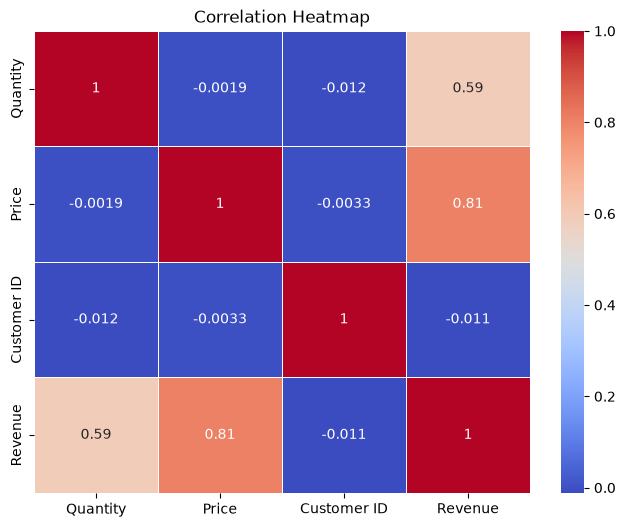

In [ ]:
##Heatmap Plot

plt.figure(figsize=(8,6))

sns.heatmap(
    Correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")


plt.show()


### Observation 


## 7. Outlier Detection

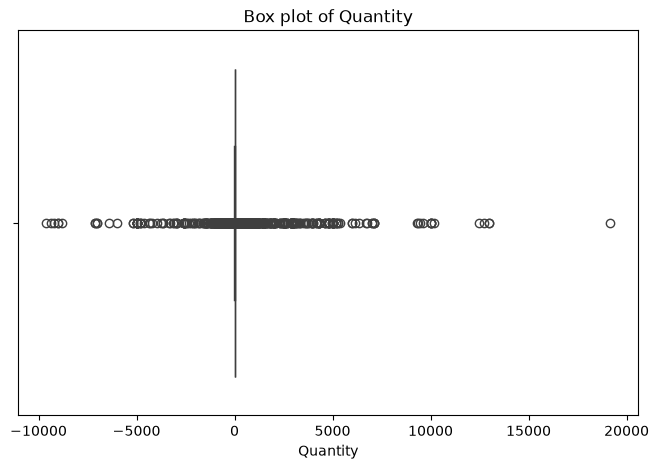

In [ ]:
## Box plot for Quantity

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Quantity"])


plt.title("Box plot of Quantity")
plt.xlabel("Quantity")

plt.show()

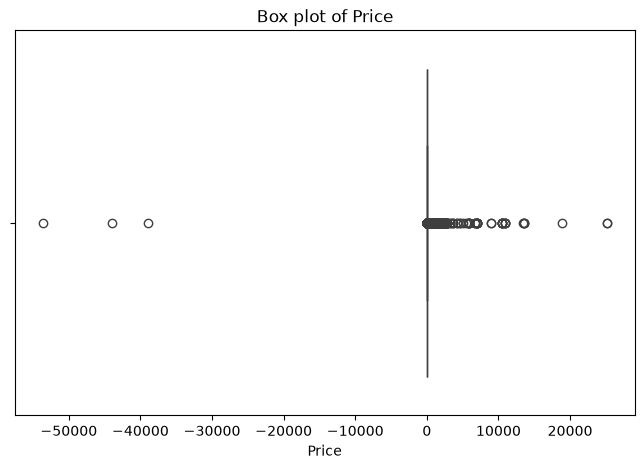

In [ ]:
## Box plot for Price

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Price"])


plt.title("Box plot of Price")
plt.xlabel("Price")

plt.show()

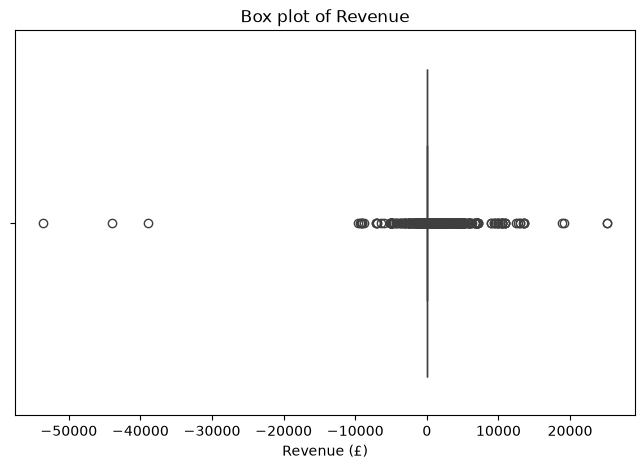

In [ ]:
## Box plot for Revenue

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Revenue"])


plt.title("Box plot of Revenue")
plt.xlabel("Revenue (£)")

plt.show()

# 8. Business insights
The following insights  are based on the exploratory  data analysis performedon the online Retail II dtaset. these observations providevaluable information that can support business decision-making.

### Insight 1: High-Demand Products
The analysis of product quantities sold revealed that a small number of products account for a significant proportion of total sales. These products should be prioritized for inventory management to reduce the risk of stock shortages and improve customer satisfaction.

### Insight 2: Revenue is not determined by Quantity alone
Products generating the highest revenue are not always those with the highest sales volume. Higher-priced products can contribute significantly to overall revenue despite being sold in smaller quantities. Pricing stratefg is therefore as important as sales volume.

### Insight 3: Revenue is Concentrated in Specific Countries
The sales by country analysis shows that revenueis heavily concentrated in a few countries, particularly the United Kingdom. this presents both an opportunity and a potential business risk, as dependence on a single market may reduce resilience against economic or market changes

### Insight 4: Revenue Changes over time
The monthly revenue trend demonstrates fluctuations in customer purchasing behavior throughout the year. Peak periods may reflect seasonal demand or promotional campaigns, suggesting that inventory planning and staffing should be adjusted to accomodate thses variations.

### Insight 5: Presence of extreme Transactions
Several outliers were identified in Quantity, Price and Revenue. These may represent wholesale purchases, product returns, premium-priced products, or data entry anomalies. Further investigating during the data cleaning stage will determinewhether these records should be retained or treated as differently.